# Intelligent Complaint Analysis for Financial Services

## Task 1

Exploratory Data Analysis and Data Preprocessing

This notebook performs:

- Data loading
- Exploratory Data Analysis
- Filtering
- Cleaning
- Saving the processed dataset

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)

plt.style.use("ggplot")

## Load Dataset

In [3]:
DATA_PATH = "../data/raw/complaints.csv"

chunks = pd.read_csv(DATA_PATH, chunksize=100000)
df = pd.concat(chunks, ignore_index=True)

C:\Users\sumex\AppData\Local\Temp\ipykernel_10868\828158700.py:4: DtypeWarning: Columns (0: Consumer disputed?) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.concat(chunks, ignore_index=True)
C:\Users\sumex\AppData\Local\Temp\ipykernel_10868\828158700.py:4: DtypeWarning: Columns (0: Consumer disputed?) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.concat(chunks, ignore_index=True)
C:\Users\sumex\AppData\Local\Temp\ipykernel_10868\828158700.py:4: DtypeWarning: Columns (0: Consumer disputed?) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.concat(chunks, ignore_index=True)
C:\Users\sumex\AppData\Local\Temp\ipykernel_10868\828158700.py:4: DtypeWarning: Columns (0: Consumer disputed?) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.concat(chunks, ignore_index=True)
C:\Users\sumex\AppData\Local\Temp\ipykernel_10868\828158700.py:4: DtypeWarning: 

In [4]:
df.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,Experian Information Solutions Inc.,FL,32092,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195687
1,2025-06-20,Debt collection,Telecommunications debt,Attempts to collect debt not owed,Debt is not yours,NaN,Company can't verify or dispute the facts in t...,"Eastern Account Systems of Connecticut, Inc.",FL,342XX,NaN,NaN,Web,2025-06-20,Closed with explanation,Yes,NaN,14195688
2,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195689
3,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,Experian Information Solutions Inc.,AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195690
4,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account status incorrect,NaN,NaN,Experian Information Solutions Inc.,IL,60628,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195692


In [5]:
df.shape

(9609797, 18)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9609797 entries, 0 to 9609796
Data columns (total 18 columns):
 #   Column                        Dtype 
---  ------                        ----- 
 0   Date received                 str   
 1   Product                       str   
 2   Sub-product                   str   
 3   Issue                         str   
 4   Sub-issue                     str   
 5   Consumer complaint narrative  str   
 6   Company public response       str   
 7   Company                       str   
 8   State                         str   
 9   ZIP code                      str   
 10  Tags                          str   
 11  Consumer consent provided?    str   
 12  Submitted via                 str   
 13  Date sent to company          str   
 14  Company response to consumer  str   
 15  Timely response?              str   
 16  Consumer disputed?            object
 17  Complaint ID                  int64 
dtypes: int64(1), object(1), str(16)
memory usage: 6.6+ GB

## Missing Values

In [7]:
df.isnull().sum().sort_values(ascending=False)

Tags                            8981029
Consumer disputed?              8841498
Consumer complaint narrative    6629041
Company public response         4770207
Consumer consent provided?      1649561
Sub-issue                        839522
Sub-product                      235295
State                             54516
ZIP code                          30228
Company response to consumer         20
Issue                                 6
Date received                         0
Product                               0
Company                               0
Date sent to company                  0
Submitted via                         0
Timely response?                      0
Complaint ID                          0
dtype: int64

## Complaint Distribution

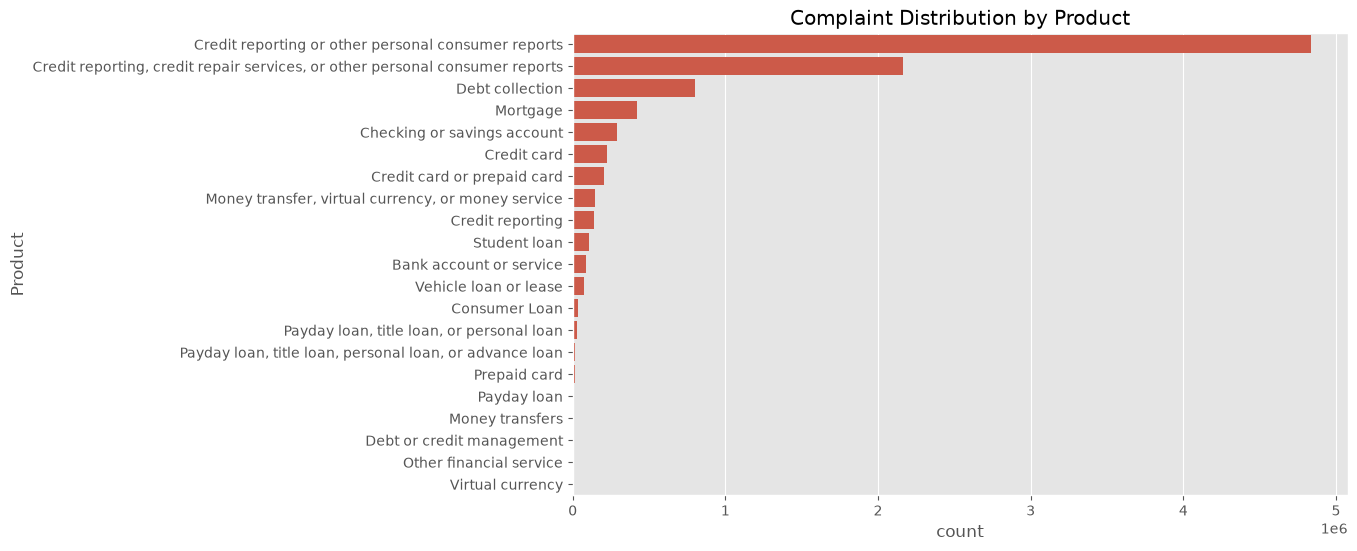

In [8]:
plt.figure(figsize=(10,6))

sns.countplot(
    y=df["Product"],
    order=df["Product"].value_counts().index
)

plt.title("Complaint Distribution by Product")
plt.show()

## Narrative Length

In [4]:
df["word_count"] = (
    df["Consumer complaint narrative"]
    .fillna("")
    .str.count(r"\S+")   # counts sequences of non-whitespace
)

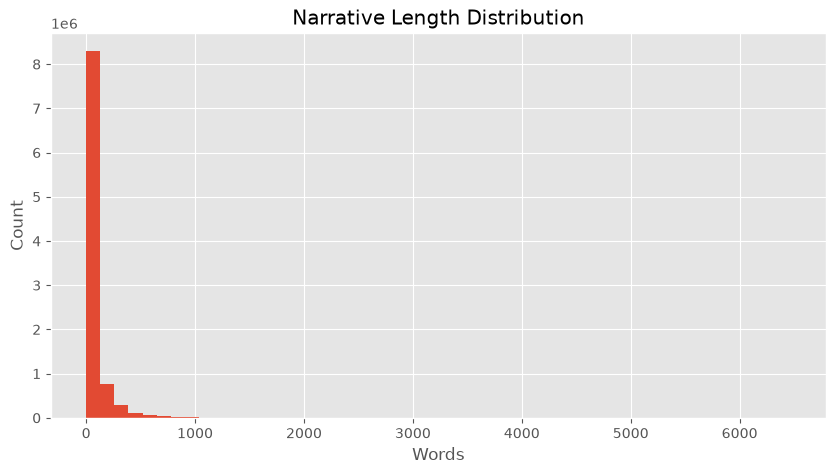

In [5]:
plt.figure(figsize=(10,5))

plt.hist(df["word_count"], bins=50)

plt.title("Narrative Length Distribution")

plt.xlabel("Words")

plt.ylabel("Count")

plt.show()

In [6]:
df["Consumer complaint narrative"].isna().sum()

np.int64(6629041)

## Filter Products

In [ ]:
products = [
    "Credit card",
    "Personal loan",
    "Savings account",
    "Money transfer"
]

In [ ]:
filtered = df[
    df["Product"].isin(products)
].copy()

In [9]:
filtered = filtered[
    filtered["Consumer complaint narrative"].notna()
]

## Text Cleaning

In [11]:
import sys
sys.path.append("..") 
from src.preprocessing import clean_text

In [12]:
filtered["clean_text"] = filtered[
    "Consumer complaint narrative"
].apply(clean_text)

In [13]:
filtered.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID,word_count,clean_text
12237,2025-06-13,Credit card,Store credit card,Getting a credit card,Card opened without my consent or knowledge,A XXXX XXXX card was opened under my name by a...,Company has responded to the consumer and the ...,"CITIBANK, N.A.",TX,78230,Servicemember,Consent provided,Web,2025-06-13,Closed with non-monetary relief,Yes,NaN,14069121,91,a xxxx xxxx card was opened under my name by a...
13280,2025-06-12,Credit card,General-purpose credit card or charge card,"Other features, terms, or problems",Other problem,"Dear CFPB, I have a secured credit card with c...",Company has responded to the consumer and the ...,"CITIBANK, N.A.",NY,11220,NaN,Consent provided,Web,2025-06-13,Closed with monetary relief,Yes,NaN,14047085,156,dear cfpb i have a secured credit card with ci...
13506,2025-06-12,Credit card,General-purpose credit card or charge card,Incorrect information on your report,Account information incorrect,I have a Citi rewards cards. The credit balanc...,Company has responded to the consumer and the ...,"CITIBANK, N.A.",IL,60067,NaN,Consent provided,Web,2025-06-12,Closed with explanation,Yes,NaN,14040217,233,i have a citi rewards cards the credit balance...
13955,2025-06-09,Credit card,General-purpose credit card or charge card,Problem with a purchase shown on your statement,Credit card company isn't resolving a dispute ...,b'I am writing to dispute the following charge...,Company has responded to the consumer and the ...,"CITIBANK, N.A.",TX,78413,Older American,Consent provided,Web,2025-06-09,Closed with monetary relief,Yes,NaN,13968411,454,b i am writing to dispute the following charge...
14249,2025-06-09,Credit card,General-purpose credit card or charge card,Problem when making payments,Problem during payment process,"Although the account had been deemed closed, I...",Company believes it acted appropriately as aut...,Atlanticus Services Corporation,NY,11212,Older American,Consent provided,Web,2025-06-09,Closed with monetary relief,Yes,NaN,13965746,170,although the account had been deemed closed i ...


In [14]:
output_path = "../data/processed/filtered_complaints.csv"

filtered.to_csv(output_path, index=False)

print("Saved successfully.")

Saved successfully.


# Key Findings

- Complaint volume varies considerably across financial products.
- Many records lack consumer narratives and were removed.
- Complaint narratives have a wide range of lengths, making chunking necessary for semantic retrieval.
- The cleaned dataset will serve as the foundation for the RAG pipeline.